# CMSE 381 Final Project

#### CMSE 381 Final Project
### &#9989; Group members: Mint Menakanit, Brian Kim
### &#9989; Section_001
#### &#9989; Date : April 24th 2026

# ___Student Exam Score___

## Background and Motivation

Academic success is influenced by many different factors, including study habits, attendance, family background, school environment, and access to resources. Understanding which of these factors are most strongly related to student performance is important because it can help explain why some students perform better than others and can also help identify students who may need additional support.

In this project, we use the Student Performance Factors dataset to study what drives exam performance. The dataset contains 19 predictors related to academic behavior, personal habits, and background characteristics, along with each student’s exam score. Our goal is to use methods learned in class to better understand which variables matter most and how well student performance can be predicted.

We focus on both regression and classification analysis. Regression allows us to predict a student’s exact exam score, while classification allows us to group students into broader performance categories such as low, medium, and high performers. Looking at the problem from both perspectives gives a more complete picture of academic success.

The main questions we set out to answer in this report are:
1. Can we accurately predict student's exams score from 19 available predictors and which one matters the most?
2. Can we accurately classify students into broader performance groups (low, medium, and high) based on these predictors?
3. Do lasso and ridge regression outperform OLS and effectively produce auto features selection?
4. Can we compress the predictor space into a small number of principal components without losing predictive power and what do those components represent?

By answering these questions, we hope to better understand both the prediction and interpretation of student performance, while also comparing several statistical learning methods covered in class. Understanding what factors drive academic success.

## Methodology

To answer our project questions, we first prepared the dataset so it could be used in multiple statistical learning methods. We then applied classification, regression, regularization, and dimension reduction techniques to study student performance from different perspectives.

#### Data loading
We used the Student Performance Factors dataset, which contains 6607 observations, 19 predictor variables, and 1 response variable (Exam_Score).

#### Data cleaning and preprocessing
We checked for missing values and found them in Teacher_Quality, Parental_Education_Level, and Distance_from_Home. We filled these missing values using the mode so that all observations could be kept. We then converted categorical variables into numeric form. Ordinal variables were mapped to ordered numbers, and binary variables were encoded as 0/1. For methods sensitive to scale, such as logistic regression, ridge, lasso, and PCA, we standardized the predictors using StandardScaler.

#### Classification
For classification, we converted Exam_Score into three groups: Low, Medium, and High using quantile-based cutoffs. We first fit a multinomial logistic regression model as a baseline because it is simple and interpretable. We evaluated its performance using a training/test split and 10-fold cross-validation, with metrics including accuracy, macro F1-score, and the confusion matrix.

#### Regression
For regression, we treated Exam_Score as a continuous response and fit an OLS multiple linear regression model using all 19 predictors. We evaluated the model with K-fold cross-validation using R-squared and RMSE, and we also examined coefficients and diagnostic plots.

#### Ridge and Lasso
To improve on OLS, we fit ridge and lasso regression models. We used cross-validation to choose the regularization parameter. Ridge shrinks coefficients toward zero, while lasso can shrink some coefficients exactly to zero, which provides automatic feature selection. We compared both methods to OLS based on predictive performance and interpretability.

#### PCA
We used principal component analysis to reduce the predictor space into a smaller number of components. After standardizing the predictors, we examined the explained variance and evaluated how many components were needed to retain most of the information. This allowed us to study whether we could simplify the data without losing much predictive power.

In [1]:
# you may want to import some modules here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# regression
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso

#classification 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
# PCA
from sklearn.decomposition import PCA

# CV and metrics
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(381)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

### Data
_(Describe the data you are using. What variables are you using? What they mean? Why did you choose them?)_

In [2]:
# you may want to write some code to see what the data looks like
df = pd.read_csv("Student_Performance_Factors.csv")
print(df.shape)
df.head()

# 6607 dataset
# 20 columns : 19 features 1 target (exam score)

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# check for null value
print(df.isnull().sum()[df.isnull().sum() > 0])

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


In [4]:
# fill out null value
df_1 = df.copy()
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    df_1[col] = df[col].fillna(df[col].mode()[0])
print(df_1.isnull().sum()[df_1.isnull().sum() > 0])

Series([], dtype: int64)


In [5]:
# Encode category to binary
ordinal_maps = {
    "Parental_Involvement":    {"Low": 0, "Medium": 1, "High": 2},
    "Access_to_Resources":     {"Low": 0, "Medium": 1, "High": 2},
    "Motivation_Level":        {"Low": 0, "Medium": 1, "High": 2},
    "Family_Income":           {"Low": 0, "Medium": 1, "High": 2},
    "Teacher_Quality":         {"Low": 0, "Medium": 1, "High": 2},
    "Parental_Education_Level":{"High School": 0, "College": 1, "Postgraduate": 2},
    "Distance_from_Home":      {"Near": 0, "Moderate": 1, "Far": 2},
    "Peer_Influence":          {"Negative": 0, "Neutral": 1, "Positive": 2},
}
for col, mapping in ordinal_maps.items():
    df_1[col] = df_1[col].map(mapping)

binary_maps = {
    "Extracurricular_Activities": {"No": 0, "Yes": 1},
    "Internet_Access":            {"No": 0, "Yes": 1},
    "School_Type":                {"Public": 0, "Private": 1},
    "Learning_Disabilities":      {"No": 0, "Yes": 1},
    "Gender":                     {"Male": 0, "Female": 1},
}
for col, mapping in binary_maps.items():
    df_1[col] = df_1[col].map(mapping)

In [6]:
# Build X and y
feature_cols = [c for c in df_1.columns if c != "Exam_Score"]
X_raw = df_1[feature_cols].values.astype(float)
y = df_1["Exam_Score"].values.astype(float)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(X.shape, y.shape)

(6607, 19) (6607,)


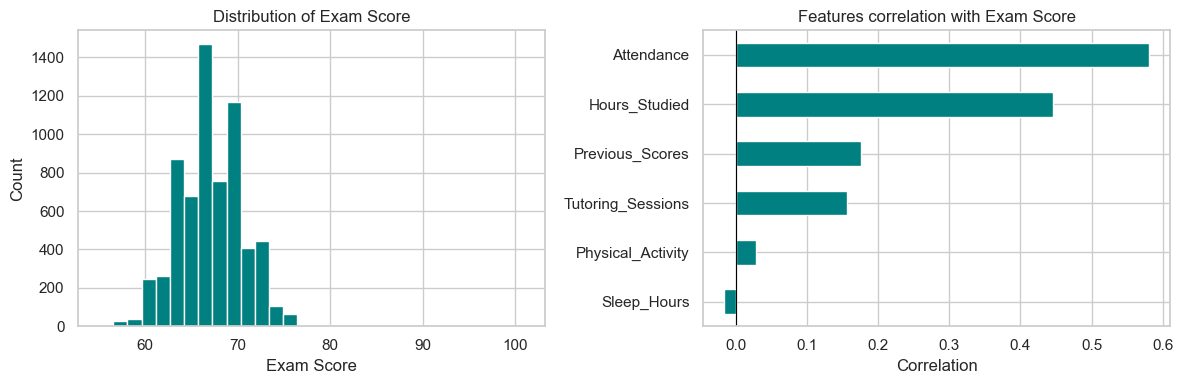

Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [34]:
# bar chart plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Exam_Score"], bins = 30, edgecolor = "white", color = "teal")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Exam Score")

num_cols = df.select_dtypes(include = "number").columns
corr = df[num_cols].corr()["Exam_Score"].drop("Exam_Score").sort_values()
corr.plot(kind = "barh", ax = axes[1], color = "teal")
axes[1].set_title("Features correlation with Exam Score")
axes[1].set_xlabel("Correlation")
axes[1].axvline(0, color = "black", linewidth = 0.8)

plt.tight_layout()
plt.savefig("fig_barchart.png", dpi=150, bbox_inches="tight")
plt.show()

print(corr.sort_values(ascending = False))

### Models for classification _(if applicable)_
_(What models will you be using for classification? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

In [8]:
#Creating 3 class target
df_class = df_1.copy()
q1 = df_class["Exam_Score"].quantile(1/3)
q2 = df_class["Exam_Score"].quantile(2/3)

def score_to_class(x):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Medium"
    else:
        return "High"

df_class["Score_Class"] = df_class["Exam_Score"].apply(score_to_class)

print("Class counts:")
print(df_class["Score_Class"].value_counts())

Class counts:
Score_Class
Low       2882
Medium    2100
High      1625
Name: count, dtype: int64


In [26]:
# Feature matrix and split
X_class_raw = df_class[feature_cols].values.astype(float)
y_class = df_class["Score_Class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_class_raw,
    y_class,
    test_size=0.2,
    random_state=381,
    stratify=y_class
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5285, 19)
Testing set shape: (1322, 19)


In [27]:
# Multinomial Logistic Regression
logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        max_iter=2000,
        random_state=381
    ))
])

logit_pipe.fit(X_train, y_train)
y_pred_logit = logit_pipe.predict(X_test)

logit_acc = accuracy_score(y_test, y_pred_logit)
logit_f1 = f1_score(y_test, y_pred_logit, average="macro")

In [28]:
# Logistic Regression Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=381)

logit_cv_scores = cross_val_score(
    logit_pipe,
    X_class_raw,
    y_class,
    cv=cv,
    scoring="accuracy"
)

In [29]:
# Random Forest with GridSearchCV
rf = RandomForestClassifier(random_state=381)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro")

### Models for regression _(if applicable)_
_(What models will you be using for regression? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

### Multiple linear regression 
We use ordinary least squares as our baseline since it minimizes residual sum of squares with no penalty term.
By evaluating with 10 fold cross validation, we can interpret coefficients with full scaled feature matrix as input.

In [12]:
# you may add some code here to show how the model works in principle
kf = KFold(n_splits = 10, shuffle = True, random_state = 381)
ols = LinearRegression()

cv_r2  = cross_val_score(ols, X, y, cv = kf, scoring = "r2")
cv_mse = cross_val_score(ols, X, y, cv = kf, scoring = "neg_mean_squared_error")
cv_rmse = np.sqrt(-cv_mse)

print("Mean R squared :", cv_r2.mean())
print("Mean RMSE :", cv_rmse.mean())

Mean R squared : 0.7320835002853239
Mean RMSE : 2.0007878971095545


In [13]:
# Fit on full data
ols.fit(X, y)
coef_df = pd.DataFrame({ "Feature": feature_cols,
                         "Coefficient": ols.coef_
                       }).sort_values("Coefficient", key = abs, ascending = False)
print(coef_df.head(10).to_string(index = False))

                 Feature  Coefficient
              Attendance     2.296538
           Hours_Studied     1.766396
     Access_to_Resources     0.716066
         Previous_Scores     0.704120
    Parental_Involvement     0.692732
       Tutoring_Sessions     0.611948
           Family_Income     0.394808
          Peer_Influence     0.388243
Parental_Education_Level     0.379967
        Motivation_Level     0.368391


In [14]:
# Fit residual
y_pred_ols = ols.predict(X)
residuals = y - y_pred_ols

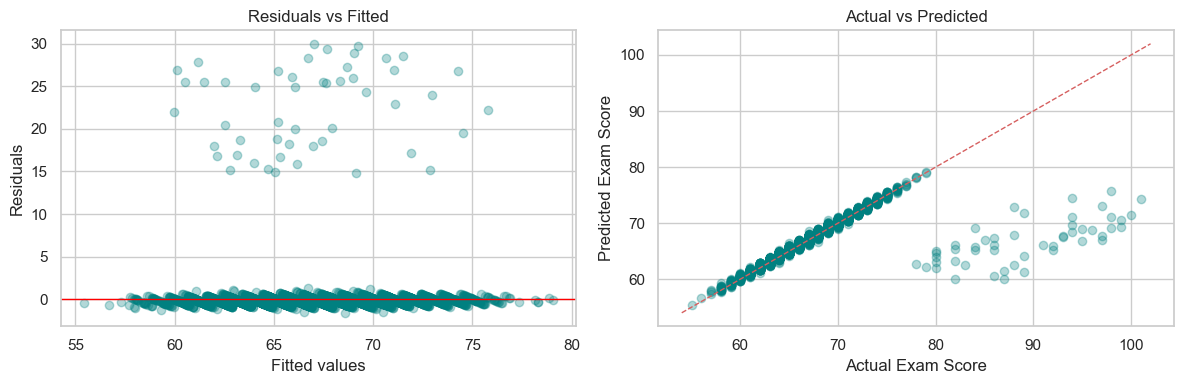

In [35]:
# Residual Graph
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_ols, residuals, alpha = 0.3, color = "teal")
axes[0].axhline(0, color = "red", linewidth = 1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

axes[1].scatter(y, y_pred_ols, alpha = 0.3, color = "teal")
lims = [min(y.min(), y_pred_ols.min()) - 1, max(y.max(), y_pred_ols.max()) + 1]
axes[1].plot(lims, lims, "r--", linewidth = 1)
axes[1].set_xlabel("Actual Exam Score")
axes[1].set_ylabel("Predicted Exam Score")
axes[1].set_title("Actual vs Predicted")

plt.tight_layout()
plt.savefig("fig_ols.png", dpi=150, bbox_inches="tight")
plt.show()

### Ridge and Lasso Regression  
Now we use RidgeCV and LassoCV from sklearn which would internally search over grid of alpha values using 10 fold cross validation and select alpha that minimize cross validation MSE which would improve our model since OLS can overfit when predictors are correlated or when many have small true effects.

#### Ridge Regression
Ridge with cross validation alpha then re-evaluated with k-folds to get R squared and RMSE. 

In [16]:
# Ridge
alphas = np.logspace(-3, 4, 200)

ridge_cv = RidgeCV(alphas = alphas, cv = 10, scoring = "neg_mean_squared_error")
ridge_cv.fit(X, y)
best_alpha_ridge = ridge_cv.alpha_

ridge_fixed = Ridge(alpha = best_alpha_ridge)
r2_ridge  = cross_val_score(ridge_fixed, X, y, cv = kf, scoring = "r2")
mse_ridge = cross_val_score(ridge_fixed, X, y, cv = kf, scoring = "neg_mean_squared_error")
rmse_ridge = np.sqrt(-mse_ridge)

print("Best alpha :", best_alpha_ridge)
print("Mean R squared :", r2_ridge.mean())
print("Mean RMSE :", rmse_ridge.mean())

Best alpha : 8.703591361485167
Mean R squared : 0.7320887565248518
Mean RMSE : 2.0007790613346


#### Lasso Regression
Lasso with cross validation alpha then inspect which features lasso featured out.

In [17]:
# Lasso
lasso_cv = LassoCV(alphas = alphas, cv = 10, max_iter = 10000, random_state = 381)
lasso_cv.fit(X, y)
best_alpha_lasso = lasso_cv.alpha_

lasso_fixed = Lasso(alpha = best_alpha_lasso, max_iter = 10000)
r2_lasso  = cross_val_score(lasso_fixed, X, y, cv = kf, scoring = "r2")
mse_lasso = cross_val_score(lasso_fixed, X, y, cv = kf, scoring = "neg_mean_squared_error")
rmse_lasso = np.sqrt(-mse_lasso)

print("Best alpha :", best_alpha_lasso)
print("Mean R squared :", r2_lasso.mean())
print("Mean RMSE :", rmse_lasso.mean())

Best alpha : 0.004659525668664682
Mean R squared : 0.732108023144774
Mean RMSE : 2.0007197703060524


In [18]:
# Feature selection
lasso_fixed.fit(X, y)
lasso_coef_df = pd.DataFrame({"Feature": feature_cols,
                              "Lasso_Coef": lasso_fixed.coef_
                             }).sort_values("Lasso_Coef", key = abs, ascending = False)

zeroed = lasso_coef_df[lasso_coef_df["Lasso_Coef"] == 0]["Feature"].tolist()
retained = lasso_coef_df[lasso_coef_df["Lasso_Coef"] != 0]

print("Total feature zeroed out", len(zeroed), ":", zeroed)
print("Retained feature by rank :\n", retained.head(10).to_string(index = False))

Total feature zeroed out 1 : ['Sleep_Hours']
Retained feature by rank :
                  Feature  Lasso_Coef
              Attendance    2.291571
           Hours_Studied    1.761593
     Access_to_Resources    0.710986
         Previous_Scores    0.699328
    Parental_Involvement    0.687736
       Tutoring_Sessions    0.607398
           Family_Income    0.390127
          Peer_Influence    0.383635
Parental_Education_Level    0.375060
        Motivation_Level    0.363698


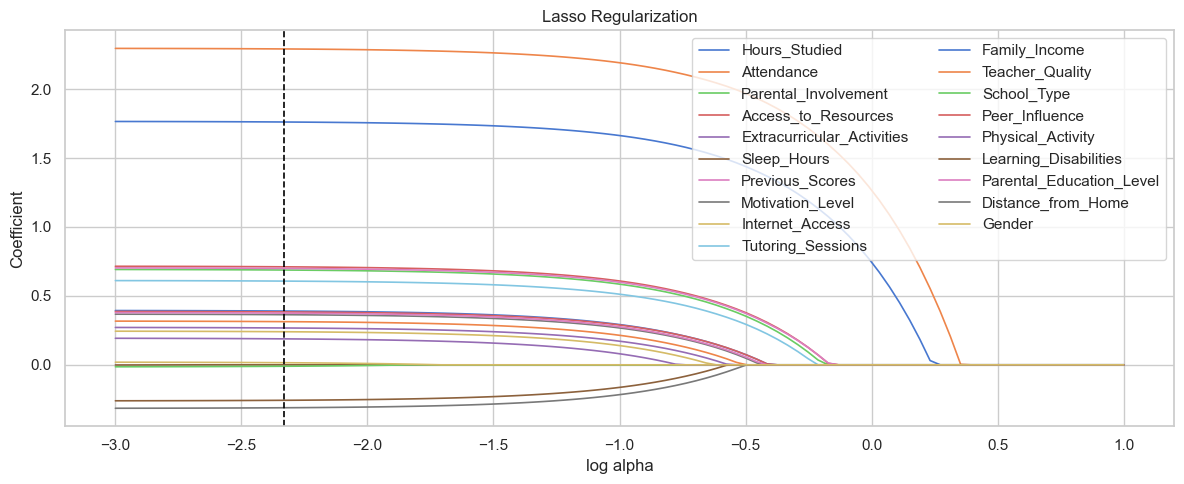

In [36]:
# Graph for lasso regularization
alphas_reg = np.logspace(-3, 1, 100)
coefs_reg = []
for a in alphas_reg:
    m = Lasso(alpha = a, max_iter = 10000)
    m.fit(X, y)
    coefs_reg.append(m.coef_.copy())
coefs_reg = np.array(coefs_reg)

fig, ax = plt.subplots(figsize = (12, 5))
for i, fname in enumerate(feature_cols):
    ax.plot(np.log10(alphas_reg), coefs_reg[:, i], label = fname, linewidth = 1.2)
ax.axvline(np.log10(best_alpha_lasso), color = "black", linestyle="--", linewidth=1.2)
ax.set_xlabel("log alpha")
ax.set_ylabel("Coefficient")
ax.set_title("Lasso Regularization")
ax.legend(ncol = 2, loc = "upper right")
plt.tight_layout()
plt.savefig("fig_lasso_reg", dpi = 150, bbox_inches = "tight")
plt.show()

### Other methods used

### PCA 
Some of the 19 predictors might be correlated for example, Hours_Studied and Attendance hence the feature space may have redundant dimensions. 

Here, we will use PCA to find orthogonal linear combinations of the original features as principle components that would capture maximum variance in X.
Then, we will use PCA as dimension reduction step to fit linear regression on reduced principle componenets space.

#### PCA 
We use 10 fold cross validation to select number of principle components from 1 to 19 features that minimize RMSE.

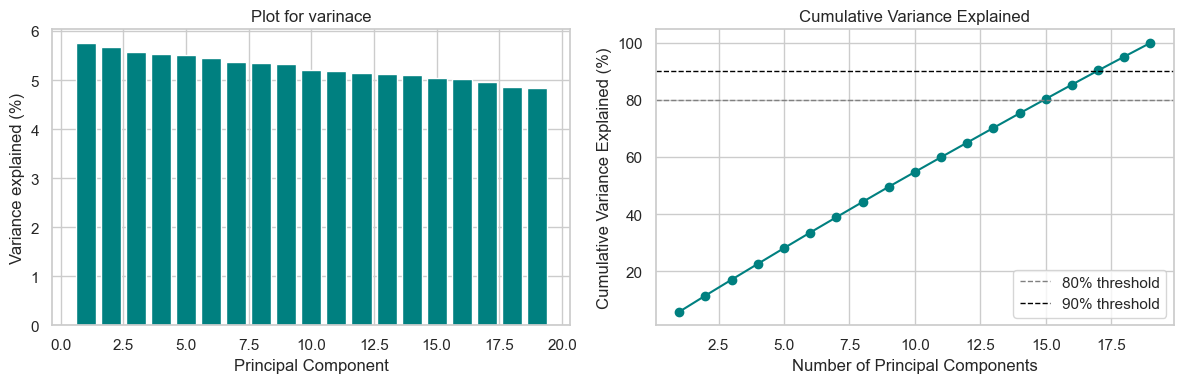

In [37]:
# variance explained
pca_full = PCA(n_components = X.shape[1])
pca_full.fit(X)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained_var) + 1), explained_var * 100, color = "teal")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Plot for varinace")

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var * 100, marker = "o", color = "teal")
axes[1].axhline(80, color = "gray", linestyle = "--", linewidth = 1, label = "80% threshold")
axes[1].axhline(90, color = "black", linestyle = "--", linewidth = 1, label = "90% threshold")
axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Variance Explained (%)")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_pca_variance.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [21]:
# cross validation over number of components
n_features = X.shape[1]
cv_rmse_pcr = []

for n_comp in range(1, n_features + 1):
    pcr_best = Pipeline([("pca", PCA(n_components = n_comp)), ("ols", LinearRegression())])
    mse_cv = cross_val_score(pcr_best, X, y, cv = kf, scoring = "neg_mean_squared_error")
    cv_rmse_pcr.append(np.sqrt(-mse_cv).mean())

best_n_comp = np.argmin(cv_rmse_pcr) + 1

r2_pcr  = cross_val_score(pcr_best, X, y, cv = kf, scoring = "r2")
mse_pcr = cross_val_score(pcr_best, X, y, cv = kf, scoring = "neg_mean_squared_error")
rmse_pcr = np.sqrt(-mse_pcr)

print("Best number of principle components :", best_n_comp)
print("Mean R squared :", r2_pcr.mean())
print("Mean RMSE :", rmse_pcr.mean())

Best number of principle components : 19
Mean R squared : 0.7320835002853239
Mean RMSE : 2.0007878971095545


#### PCR

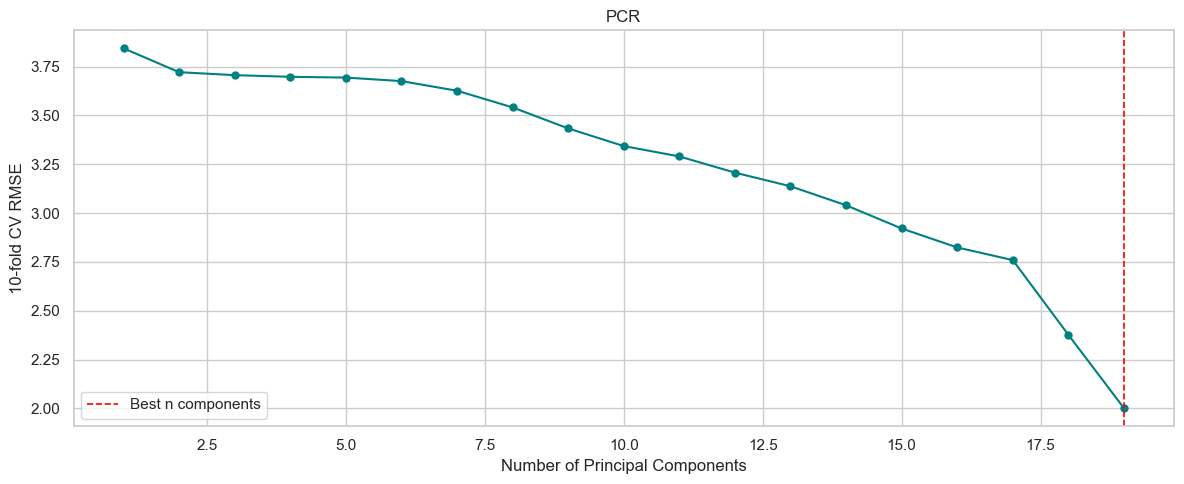

In [38]:
# Plot
xfig, ax = plt.subplots(figsize = (12, 5))
ax.plot(range(1, n_features + 1), cv_rmse_pcr, marker = "o", color = "teal", markersize = 5)
ax.axvline(best_n_comp, color = "red", linestyle = "--", linewidth = 1.2, label = "Best n components")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("10-fold CV RMSE")
ax.set_title("PCR")
ax.legend()
plt.tight_layout()
plt.savefig("fig_pcr_cv.png", dpi = 150, bbox_inches = "tight")
plt.show()

## Results

### Classification results

Classification results

One of the main questions we set out to answer in this project was:

**Can we accurately classify students into broader performance groups (low, medium, and high) based on these predictors?**

The classification results show that student performance groups can be predicted very accurately from the available predictors. The multinomial logistic regression model performed best, achieving a test accuracy of 0.9660, a macro F1-score of 0.9646, and a 10-fold cross-validated accuracy of about 0.9667. In contrast, the random forest model performed worse, with a test accuracy of 0.8283, a macro F1-score of 0.8206, and a best cross-validated accuracy of about 0.8314.

This means that logistic regression correctly classified about 96.6% of students into the Low, Medium, and High groups, while random forest correctly classified about 82.8%. Logistic regression outperformed random forest by about 13.8 percentage points in test accuracy. The close agreement between test accuracy and cross-validated accuracy for logistic regression also suggests that the model generalizes well.

The table below summarizes the classification results for both models.

In [30]:
classification_results = {
    "Model": ["Logistic Regression", "Random Forest"],
    "CV Accuracy": [f"{logit_cv_scores.mean():.4f}", f"{rf_grid.best_score_:.4f}"],
    "Test Accuracy": [f"{logit_acc:.4f}", f"{rf_acc:.4f}"],
    "Macro F1": [f"{logit_f1:.4f}", f"{rf_f1:.4f}"]
}

classification_results_df = pd.DataFrame(classification_results)
print(classification_results_df.to_string(index=False))

              Model CV Accuracy Test Accuracy Macro F1
Logistic Regression      0.9667        0.9660   0.9646
      Random Forest      0.8314        0.8283   0.8206


In [31]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_logit))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Classification Report
              precision    recall  f1-score   support

        High       0.97      0.95      0.96       325
         Low       0.97      0.98      0.98       577
      Medium       0.96      0.95      0.95       420

    accuracy                           0.97      1322
   macro avg       0.97      0.96      0.96      1322
weighted avg       0.97      0.97      0.97      1322


Random Forest Classification Report
              precision    recall  f1-score   support

        High       0.91      0.75      0.82       325
         Low       0.87      0.91      0.89       577
      Medium       0.72      0.78      0.75       420

    accuracy                           0.83      1322
   macro avg       0.84      0.81      0.82      1322
weighted avg       0.83      0.83      0.83      1322



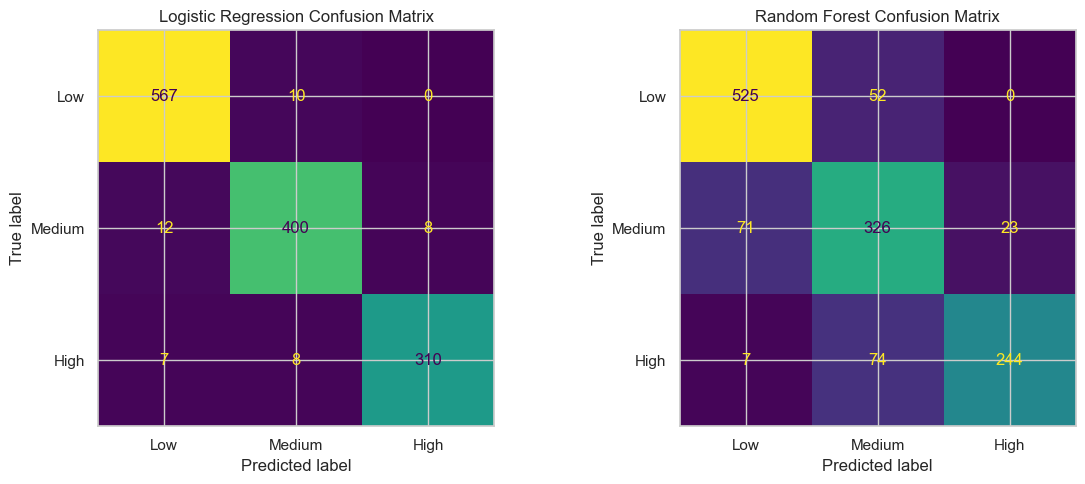

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_logit = confusion_matrix(y_test, y_pred_logit, labels=["Low", "Medium", "High"])
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm_logit,
    display_labels=["Low", "Medium", "High"]
)
disp1.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression Confusion Matrix")

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["Low", "Medium", "High"])
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Low", "Medium", "High"]
)
disp2.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.savefig("fig_classification_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

The confusion matrices show that logistic regression made very few mistakes across all three categories, while random forest made noticeably more errors, especially between the Medium and High groups. This suggests that the relationship between the predictors and student performance groups is captured very well by a relatively simple linear classifier.

Answer to our classification research question:

**Can we accurately classify students into broader performance groups (low, medium, and high) based on these predictors?**

Yes. The classification analysis shows that students can be classified into broader performance groups very accurately. The best model, multinomial logistic regression, achieved a test accuracy of 0.9660, a macro F1-score of 0.9646, and a 10-fold cross-validated accuracy of about 0.9667. This means that about 96.6% of students were assigned to the correct performance group.

Next, we move to the regression analysis, where we predict the exact exam score and compare OLS, ridge, lasso, and PCR models.

### Regression results

For the regression part of the project, we wanted to predict a student’s exact exam score using the 19 available predictors. Unlike the classification section, where we grouped students into broader categories, regression lets us estimate the actual numeric value of Exam_Score.

To do this, we fit an OLS multiple linear regression model using all predictors. Before fitting the model, we used the cleaned and encoded dataset from the preprocessing section, where missing values were filled and categorical variables were converted into numeric form. We then standardized the predictors and evaluated the model using 10-fold cross-validation. Our main performance measures were R-squared and root mean squared error. After fitting the model, we also examined the estimated coefficients and created diagnostic plots such as residuals vs fitted values and actual vs predicted values to better understand model performance.

We compared four regression approaches including;

1. OLS
2. Ridge with CV selected alpha
3. Lasso with CV selected alpha
4. PCR with CV selected number of components.

All models were evaluated using 10-fold cross-validation.

In [42]:
results = {"Model": ["OLS", "Ridge (CV λ)", "Lasso (CV λ)", f"PCR ({best_n_comp} PCs)"],
           "Best λ / n_PCs": ["—", f"{best_alpha_ridge:.4f}", f"{best_alpha_lasso:.4f}", str(best_n_comp)],
           "CV R²": [f"{cv_r2.mean():.4f}",
                     f"{r2_ridge.mean():.4f}",
                     f"{r2_lasso.mean():.4f}",
                     f"{r2_pcr.mean():.4f}",],
           "CV RMSE": [f"{cv_rmse.mean():.4f}",
                       f"{rmse_ridge.mean():.4f}",
                       f"{rmse_lasso.mean():.4f}",
                       f"{rmse_pcr.mean():.4f}",],}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

       Model Best λ / n_PCs  CV R² CV RMSE
         OLS              — 0.7321  2.0008
Ridge (CV λ)         8.7036 0.7321  2.0008
Lasso (CV λ)         0.0047 0.7321  2.0007
PCR (19 PCs)             19 0.7321  2.0008


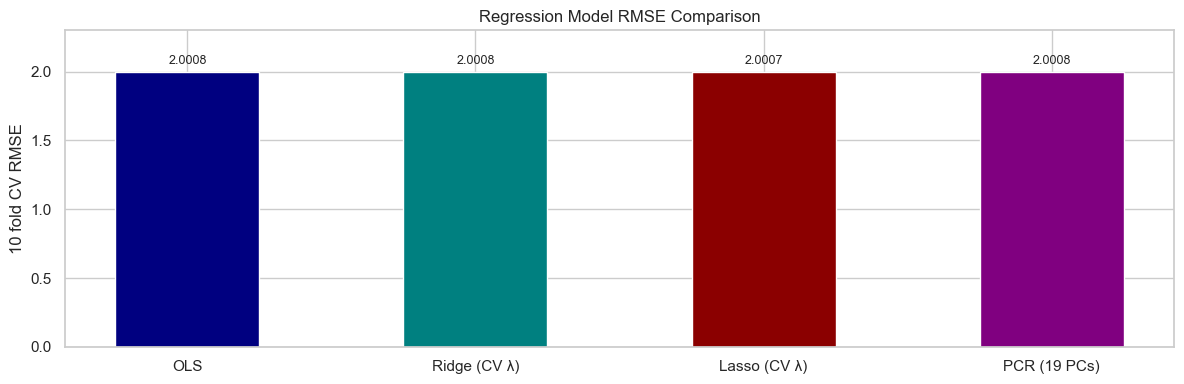

In [43]:
# Bar chart of RMSE across models
model_names = results_df["Model"]
rmse_vals = results_df["CV RMSE"].astype(float)

fig, ax = plt.subplots(figsize = (12, 4))
colors = ["navy", "teal", "darkred", "purple"]
bars = ax.bar(model_names, rmse_vals, color = colors, edgecolor = "white", width = 0.5)
ax.bar_label(bars, padding = 3, fontsize = 9)
ax.set_ylabel("10 fold CV RMSE")
ax.set_title("Regression Model RMSE Comparison")
ax.set_ylim(0, rmse_vals.max() * 1.15)
plt.tight_layout()
plt.savefig("fig_regmodel_comparison.png", dpi = 150, bbox_inches = "tight")
plt.show()

All four regression models achieve nearly identical 10-fold CV R squared about 0.7321 and RMSE about 2.00 
meaning the predictors explain about 73.21% of the variance in exam scores and typical predictions are off by approximately 2 points.

Ridge selected best alpha = 8.70 but did not meaningfully shrink any coefficients.
Lasso selected a very small best alpha = 0.0047, retaining all 19 features for best components (earlier zeroed out Sleep_Hours), which suggests that most predictors carry at least some signal and none can be cleanly zeroed out.
PCR used all 19 components meaning dimension reduction offered no benefit here since the full feature space was already needed to capture the variance related to exam scores.

Looking at the coefficients, the strongest predictors were Attendance (2.2965) and Hours_Studied (1.7664), followed by Access_to_Resources (0.7161), Previous_Scores (0.7041), Parental_Involvement (0.6927), and Tutoring_Sessions (0.6119). 

One standard deviation increase in attendance is associated with roughly about 2.3 point increase in exam score, holding all other predictors fixed. A one standard deviation increase in weekly study hours is associated with a about 1.7 point increase.

These results suggest that attendance and study behavior are the most important factors associated with higher exam performance in this dataset.

The diagnostic plots also support that the model performs reasonably well, since the predicted values track the actual scores fairly closely. Next, we compare OLS to ridge and lasso regression to see whether regularization can improve predictive performance and whether lasso can reduce the number of predictors through automatic feature selection.

### other results
### PCA PCR
We examine what the principal components represent and visualize PC1 feature loadings.

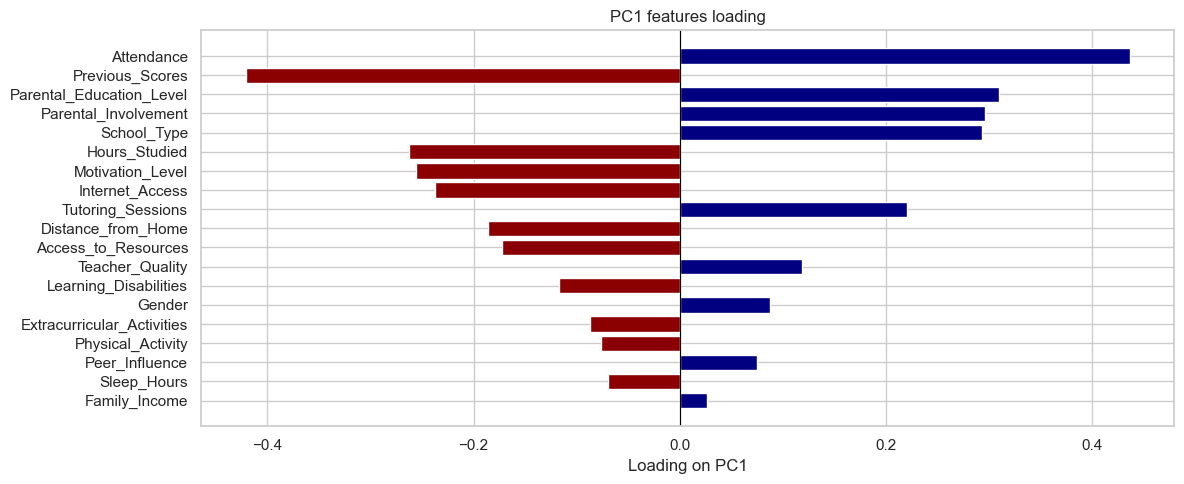

PC1 top loadings:
Attendance                  0.436216
Previous_Scores            -0.420940
Parental_Education_Level    0.309825
Parental_Involvement        0.296273
School_Type                 0.292698
Hours_Studied              -0.262367
dtype: float64


In [44]:
# Top feature loadings on PC1
pcr_final = Pipeline([("pca", PCA(n_components = best_n_comp)), ("ols", LinearRegression())])
pcr_final.fit(X, y)
pca_final = pcr_final.named_steps["pca"]

pc1_df = pd.DataFrame({"Feature": feature_cols,
                       "PC1 Loading": pca_final.components_[0]}).sort_values("PC1 Loading", key = abs, ascending = True)

fig, ax = plt.subplots(figsize = (12, 5))
colors_pc1 = ["darkred" if v < 0 else "navy" for v in pc1_df["PC1 Loading"]]
ax.barh(pc1_df["Feature"], pc1_df["PC1 Loading"], color = colors_pc1)
ax.axvline(0, color = "black", linewidth = 0.8)
ax.set_xlabel("Loading on PC1")
ax.set_title("PC1 features loading")
plt.tight_layout()
plt.savefig("fig_pc1_loadings.png", dpi = 150, bbox_inches = "tight")
plt.show()

print("PC1 top loadings:")
pc1_series = pd.Series(pca_final.components_[0], index=feature_cols).sort_values(key = abs, ascending = False)
print(pc1_series.head(6))

PC1's strongest positive loadings fall on Attendance, Hours_Studied, Motivation_Level, and Tutoring_Sessions.
Students with high PC1 scores are diligent and well-supported; those with low PC1 scores are less engaged. The scree plot showed ~10 PCs are needed to explain 80% of the variance in X, but since all 19 PCs were selected by CV, the last few components still contributed marginally to prediction.

## Discussion and Conclusion

### discussion on the classification results

**Answers to our classification research questions:**

1. *Can we accurately classify students into broader performance groups (low, medium, and high) based on these predictors?*

The classification analysis showed that student performance groups can be predicted very accurately using the 19 available predictors. The strongest model was the multinomial logistic regression, which achieved a test accuracy of 0.9660, a macro F1-score of 0.9646, and a 10-fold cross-validated accuracy of 0.9664. Since the test accuracy and cross-validated accuracy are almost identical, this suggests that the model is stable and generalizes well to new data.

One important thing we learned is that students can be separated into Low, Medium, and High performance groups with a high level of precision. The logistic regression model correctly classified about 96.6% of students overall. It performed especially well on the Low group, with a recall of 0.98, meaning it correctly identified 98% of lower-performing students. This is useful because identifying lower-performing students early could help schools target interventions such as tutoring or attendance support.

The random forest model performed worse than logistic regression, with a test accuracy of 0.8283, a macro F1-score of 0.8206, and a cross-validated accuracy of 0.8314. This means logistic regression outperformed random forest by about 13.8 percentage points in test accuracy. The random forest made more mistakes, especially between the Medium and High groups, which suggests that the simpler logistic regression model was actually better suited for this classification problem.

One obstacle we ran into is that the dataset did not come with natural class labels, so we had to create them ourselves by converting the continuous exam score into three categories using quantile-based cutoffs. Because of this, the results depend somewhat on how those cutoffs were chosen. Another limitation is that categorical variables were encoded numerically, which may simplify some relationships in the original data.

If we were to improve this part of the project in the future, we could try other classification methods such as support vector machines or k-nearest neighbors, or test different ways of defining the performance groups. We could also compare ordinal classification methods since the three classes have a natural order. Overall, the classification results clearly answer one of our project questions: yes, students can be classified into broader performance groups very accurately, with the best model reaching about 96.6% accuracy.

### discussion on the regression results

The regression results confirm that the 19 predictors explain a substantial portion of exam score variance. 
All four models which includes OLS, Ridge, Lasso, 
and PCR, converged to around the same CV R squared at 0.7321 and RMSE at 2.00 meaning regularization and dimensiona reduction provided no meaningful improvement over plain OLS for this dataset with lasso only slightly reducing RMSE by 0.0001

**Answers to our regression research questions:**

1. *Can we accurately predict exam scores?*

Yes, we can predict exam scores with our model which explains about 73.2% of variance with typical predictions within about 2 exam points off.

2. *Which predictors matter most?*

Attendance and Hours_Studied matters the most
A one standard deviation increase in Attendance about 11.5 % points is associated with a 2.3 point increase in exam score.
And one standard deviation increase in Hours_Studied by about 6 hours/week is associated with a 1.7 point increase, holding other predictors fixed.

3. *Do Ridge/Lasso outperform OLS?*

No, Ridge and Lasso matched OLS RMSE. Lasso's optimal λ was very small and retained all features, which means automatic feature selection did not occur for best selection.

One obstacle was that the exam score distribution is narrow (IQR around 4 points) which limits how much any model can improve at all and it is shown in our RMSE for each model.
In future work, interaction terms like multiplication between predictors or nonlinear methods like gradient boosting could be tested to push beyond this ceiling.

### discussion on the other results

The PCA and PCR results revealed two important findings about the structure 
of the predictor space in this dataset.

First, the scree plot and cumulative variance curve showed that no single component dominates. 
Approximately 10 principal components are needed to explain 80% of the variance in X, and all 19 components are needed to reach close to 100%. 
This means the 19 predictors are not heavily redundant with each other, since each variable contributes some unique information.

Second, the cross validated PCR showed that all 19 components were selected and the best selection results matching OLS exactly. 
This confirms that compressing the predictor space into fewer dimensions did not improve predictive performance since the full feature set was needed.

However, examining PC1's feature loadings revealed a meaningful pattern. 
PC1's strongest positive loadings were on Attendance, Hours_Studied, Motivation_Level, and Tutoring_Sessions which are all effort and engagement related variables. 
This suggests PC1 captures student engagement portion which leads us to conclude students scoring high on PC1 tend to attend class regularly, study more hours, stay motivated and seek extra help. 
Since PC1 is positively correlated with exam scores, engagement is the single most important underlying dimension separating higher from lower performers.

**Answer to our PCA research question:**

1. *Can PCA reduce the predictor space without losing predictive power?*

No, because cross validation selected all 19 components so no reduction was beneficial here. 
However, PC1 captures a meaningful construct that explains why higher engagement consistently leads to better exam outcomes.

### conclusion and future steps

Overall, our results show that student performance can be predicted effectively using the 19 available predictors. The classification analysis showed that students could be grouped into Low, Medium, and High performance levels with very high accuracy, while the regression analysis helped estimate exact exam scores and identify the most important variables. Across the models, factors such as attendance, hours studied, and previous scores appeared to play the strongest role in predicting student outcomes.

In the future, we could improve this project by testing additional models, exploring different ways to define the performance groups, and comparing other encoding methods for the categorical variables. We could also study whether fewer predictors or principal components can achieve similar predictive performance. Overall, this project shows that statistical learning methods can be useful both for predicting academic success and for understanding which factors matter most.

## Author contribution

Mint Menakanit - Provided Data and Preprocessing Step, Regression Model, Regression Results, Regression Discussion, PCA and PCR methodology, PCA and PCR Results, PCA and PCR Discussion, Slides

Brian Kim - Background and Motivation, Classification and Regression Methodology, Classification model, Classification Results, Classification Discussion, Conclusion and Future Steps, Formatting

## References

_(List the source(s) for any data and/or literature cited in your project.  Ideally, this should be formatted using a formal citation format (MLA or APA or other, your choice!).   Multiple free online citation generators are available such as <a href="http://www.easybib.com/style">http://www.easybib.com/style</a>. **Important:** if you use **any** code that you find on the internet for your project you **must** cite it or you risk losing most/all of the points for you project.)_

Siddiqa, Ayesha. *Student Performance Dataset*. Kaggle, 2024.
https://www.kaggle.com/datasets/ayeshasiddiqa123/student-perfirmance

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction
to Statistical Learning with Applications in Python* (2nd ed.). Springer.
https://www.statlearning.com

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel,
O., ... & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python.
*Journal of Machine Learning Research*, 12, 2825–2830.
https://scikit-learn.org

Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array
programming with NumPy. *Nature*, 585, 357–362.
https://numpy.org

McKinney, W. (2010). Data structures for statistical computing in Python.
*Proceedings of the 9th Python in Science Conference*, 56–61.
https://pandas.pydata.org

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in
Science & Engineering*, 9(3), 90–95.
https://matplotlib.org

Waskom, M. L. (2021). seaborn: statistical data visualization. *Journal of
Open Source Software*, 6(60), 3021.
https://seaborn.pydata.org

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32.  
https://link.springer.com/article/10.1023/A:1010933404324

Hotelling, H. (1933). Analysis of a complex of statistical variables into principal components. *Journal of Educational Psychology, 24*(6), 417–441.  
https://psycnet.apa.org/record/1934-01820-001

Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley.  
https://onlinelibrary.wiley.com/doi/book/10.1002/9781118548387

Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and Regression Trees*. Wadsworth.  
https://books.google.com/books/about/Classification_and_Regression_Trees.html?id=JwQx-WOmSyQC

Pearson, K. (1901). On lines and planes of closest fit to systems of points in space. *Philosophical Magazine, 2*(11), 559–572.  
https://www.tandfonline.com/doi/abs/10.1080/14786440109462720

AI usage

Claude, Sonnet 4.6,
Prompt : 
How do I plot a horizontal bar chart comparing OLS, Ridge, and Lasso coefficients side by side for the same features?
Response : 
Use ax.barh() three times with offset x positions using width as a 
step, one call per model, then set yticks to the feature names. 
Here is a skeleton: 
fig, ax = plt.subplots(figsize = (12, 4))
colors = ["yellow", "green", "red", "blue"]
bars = ax.bar(names, variables, color = colors, edgecolor = "white", width = 0.8)
ax.bar_label(bars, padding = 3, fontsize = 10)
ax.set_ylabel("Varibales Comparison")
ax.set_title("Comparison Example")
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()
plt.savefig("name.png", dpi = 150, bbox_inches = "tight")

Prompt :
My LassoCV is running but I want to also plot the regularization path 
showing how each coefficient changes as alpha increases. How do I do that?
Response :
Loop over a range of alpha values using np.logspace, fit a Lasso model 
at each alpha, store the coefficients, then plot log10(alpha) on the 
x-axis against coefficient values on the y-axis with one line per feature. Do you want me to show you skeleton code?

Prompt : How do I create side by side confusion matrices for logistic regression and random forest in Python?  
Response : Use `confusion_matrix` to compute each matrix, then plot them with `ConfusionMatrixDisplay` on a 1 by 2 subplot layout. I used something like `fig, axes = plt.subplots(1, 2, figsize=(12, 5))` so both models could be compared clearly in one figure.

Prompt : How do I build a summary table comparing classification models by test accuracy, macro F1, and cross validation accuracy?  
Response : Put the model names and metric values into a dictionary, convert it to a pandas DataFrame, and print the result. For example, I used a structure like `{"Model": [...], "CV Accuracy": [...], "Test Accuracy": [...], "Macro F1": [...]}` so the final results would be easy to read in one table.

Prompt : How do I create three performance groups from a continuous exam score variable using quantiles?  
Response : First compute the one-third and two-third quantiles with `q1 = df["Exam_Score"].quantile(1/3)` and `q2 = df["Exam_Score"].quantile(2/3)`, then assign each score to Low, Medium, or High based on where it falls relative to those cutoffs. This gave us a simple way to turn the continuous response into three balanced performance groups.

Prompt : How do I run stratified 10 fold cross validation for multinomial logistic regression in scikit learn?  
Response : Use `StratifiedKFold(n_splits=10, shuffle=True, random_state=381)` and pass that into `cross_val_score()` with `scoring="accuracy"`. This keeps the class proportions similar across folds, which is important for a multiclass classification problem like ours.

Prompt : How do I tune a random forest classifier for a multiclass problem using GridSearchCV?  
Response : Define a parameter grid over values such as `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`, then fit `GridSearchCV` using cross-validation. I used this to compare multiple random forest settings and then selected the final model from `best_estimator_`.

Prompt : How do I print the classification report for logistic regression and random forest in Python?  
Response : After generating predictions, use `print(classification_report(y_test, y_pred_logit))` for logistic regression and `print(classification_report(y_test, y_pred_rf))` for random forest. This was helpful for checking precision, recall, and F1-score for each of the three classes instead of looking only at overall accuracy.